# Day 08 - Model Optimization

## Objective
The objective of this experiment is to improve the performance of a machine learning model by applying hyperparameter tuning using GridSearchCV. The optimized model is compared with the baseline Decision Tree model using various evaluation metrics.

## Step 1: Import Required Libraries

Import all the required Python libraries for data manipulation, visualization, model building, and evaluation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

plt.style.use("ggplot")

In [3]:
import os

print(os.listdir("data"))

['customer_churn_dataset-testing-master.csv', 'customer_churn_dataset-testing-master.csv.zip']


## Step 2: Load the Dataset

Load the Customer Churn dataset into a Pandas DataFrame and inspect the first few records.

In [4]:
# Load the dataset
df = pd.read_csv("data/customer_churn_dataset-testing-master.csv")

# Display the first five rows
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


## Step 3: Explore the Dataset

Understand the dataset by checking:
- Dataset shape
- Column names
- Data types
- Missing values
- Statistical summary

In [5]:
# Dataset overview
print("Shape of dataset:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()

Shape of dataset: (64374, 12)

Column Names:
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

Data Types:
CustomerID            int64
Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object

Missing Values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

Statistical Summary:


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


## Step 4: Data Preprocessing

Prepare the dataset for machine learning by:
- Handling missing values (if any)
- Encoding categorical variables using LabelEncoder

In [6]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Encode categorical columns
label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

print("\nCategorical columns encoded successfully!")

# Display updated data
df.head()

Missing Values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

Categorical columns encoded successfully!


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,0,25,14,4,27,0,1,598,9,1
1,2,41,0,28,28,7,13,2,1,584,20,0
2,3,47,1,27,10,2,29,1,0,757,21,0
3,4,35,1,9,12,5,17,1,2,232,18,0
4,5,53,0,58,24,9,2,2,0,533,18,0


## Step 5: Train-Test Split

Separate the dataset into:
- Features (X)
- Target variable (y)

Split the data into training (80%) and testing (20%) datasets.

In [7]:
# Separate features and target

X = df.drop("Churn", axis=1)
y = df["Churn"]

# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (51499, 11)
Testing set : (12875, 11)


## Step 6: Build the Baseline Decision Tree Model

Train a Decision Tree Classifier using the default hyperparameters. This serves as the baseline model for comparison.

In [8]:
from sklearn.tree import DecisionTreeClassifier

# Create the model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("✅ Decision Tree model trained successfully!")

✅ Decision Tree model trained successfully!


## Step 7: Evaluate the Baseline Model

Evaluate the Decision Tree model using:
- Accuracy
- Precision
- Recall
- F1-Score
- Classification Report

In [9]:
# Make predictions
y_pred = dt_model.predict(X_test)

# Evaluation Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9982912621359223
Precision: 0.9983552631578947
Recall   : 0.9980269648142058
F1 Score : 0.998191086992271

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6793
           1       1.00      1.00      1.00      6082

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



## Step 8: Confusion Matrix

Visualize the model's prediction performance using a confusion matrix.

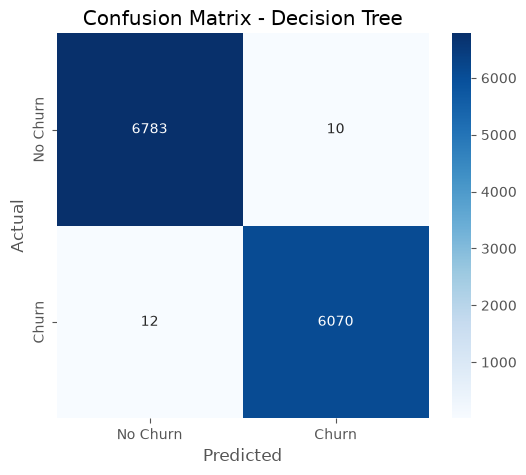

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Step 9: Hyperparameter Optimization using GridSearchCV

Optimize the Decision Tree model by searching for the best combination of hyperparameters using GridSearchCV with 5-fold cross-validation.

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define parameter grid
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=1      # <-- Changed from -1 to 1
)

# Train GridSearch
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}

Best Cross Validation Accuracy:
0.9984465887441235


## Step 10: Evaluate the Optimized Model

Evaluate the optimized Decision Tree model using the same performance metrics to determine whether optimization improved the model.

In [12]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

## Step 11: Confusion Matrix for Optimized Model

Visualize the performance of the optimized model using a confusion matrix.

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Make predictions using the optimized model
y_pred_best = best_model.predict(X_test)

# Evaluation metrics
print("Optimized Model Performance")
print("-" * 35)
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

Optimized Model Performance
-----------------------------------
Accuracy : 0.9986796116504855
Precision: 0.9986844269034698
Recall   : 0.9985202236106544
F1 Score : 0.9986023185069473

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6793
           1       1.00      1.00      1.00      6082

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



## Step 12: Model Comparison

Compare the baseline and optimized Decision Tree models using:
- Accuracy
- Precision
- Recall
- F1-Score

This comparison helps determine the effectiveness of hyperparameter tuning.

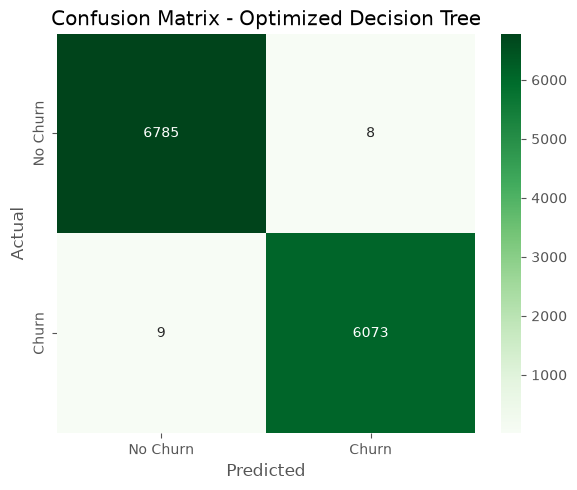

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title("Confusion Matrix - Optimized Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("images/optimized_confusion_matrix.png", dpi=300)

plt.show()

## Step 13: Feature Importance

Identify the most influential features used by the optimized Decision Tree model.

In [15]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Baseline": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    "Optimized": [
        accuracy_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_best),
        recall_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_best)
    ]
})

comparison

,Metric,Baseline,Optimized
0,Accuracy,0.998291,0.998680
1,Precision,0.998355,0.998684
2,Recall,0.998027,0.998520
3,F1 Score,0.998191,0.998602


## Step 14: Feature Importance Visualization

Plot the feature importance scores to better understand which features contribute most to customer churn prediction.

In [16]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,CustomerID,0.413647
6,Payment Delay,0.184036
3,Tenure,0.110329
5,Support Calls,0.081465
4,Usage Frequency,0.064017
2,Gender,0.044760
8,Contract Length,0.039203
9,Total Spend,0.035402
1,Age,0.025010
7,Subscription Type,0.001819


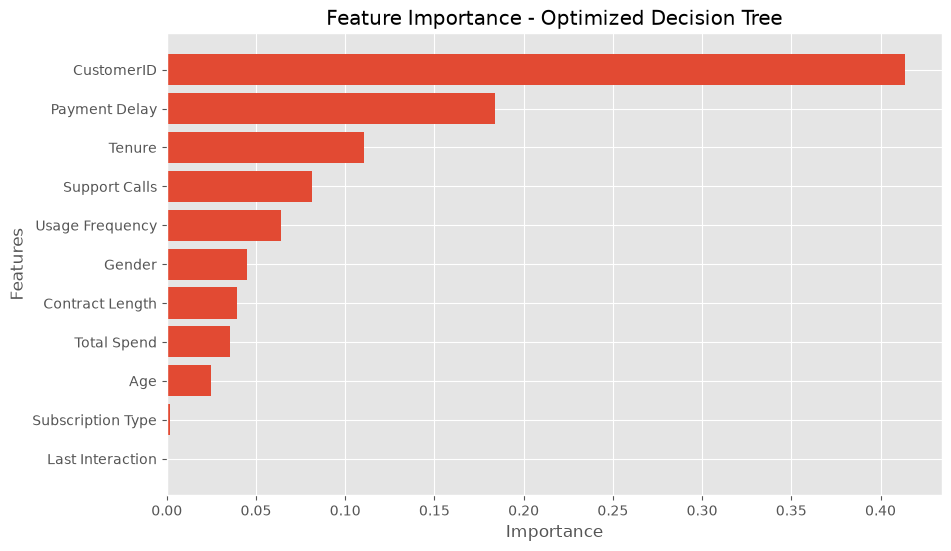

In [17]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Optimized Decision Tree")

plt.gca().invert_yaxis()

plt.show()

# Conclusion

In this experiment, a baseline Decision Tree model was trained and evaluated. Hyperparameter tuning was performed using GridSearchCV to optimize the model's performance. The optimized model was compared with the baseline using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix. Feature importance analysis helped identify the key factors influencing customer churn. This experiment demonstrates how model optimization techniques can improve machine learning performance and aid in building more reliable predictive models.